# 📊 Startup Funding Analysis in India

## Project Overview

The Indian startup ecosystem has experienced remarkable growth over the past decade, attracting investments from venture capital firms, angel investors, private equity organizations, and institutional investors. Understanding funding trends is essential for entrepreneurs seeking investment, investors evaluating business opportunities, and policymakers supporting innovation.

This project performs an Exploratory Data Analysis (EDA) on an Indian startup funding dataset to uncover investment patterns, identify major startup hubs, analyze industry-wise funding distribution, evaluate investor participation, and study funding trends over time.

The project demonstrates practical applications of data cleaning, preprocessing, visualization, and business insight generation using Python.

---

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- google colab

---

### Skills Demonstrated

- Data Cleaning
- Data Preprocessing
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Insight Generation
- Statistical Analysis

# Business Problem

India has become one of the fastest-growing startup ecosystems in the world. Thousands of startups receive investments every year across different industries and cities. However, identifying meaningful investment patterns from raw funding data can be challenging.

This project aims to answer several important business questions:

- Which cities attract the highest startup investments?
- Which industries receive maximum funding?
- Which investors participate most frequently?
- How has startup funding evolved over time?
- What is the overall distribution of startup funding?

The answers to these questions provide valuable insights for entrepreneurs, investors, researchers, and policymakers.

# Project Objectives

The primary objectives of this analysis are:

- Study startup funding trends over different years.
- Identify the most active startup ecosystems in India.
- Analyze industry-wise investment distribution.
- Examine investor participation patterns.
- Understand funding amount distribution.
- Generate meaningful business insights using exploratory data analysis.

# Dataset Description

The dataset contains historical records of startup funding in India.

### Dataset Features

- Startup Name
- Industry Vertical
- City Location
- Investment Type
- Investors
- Funding Amount
- Funding Date

These features are used to analyze funding patterns, identify startup ecosystems, evaluate investment behavior, and generate business insights.

# Import Required Libraries

Python libraries are imported for data manipulation, numerical computation, and visualization.

**Pandas** is used for data manipulation.

**NumPy** performs numerical operations.

**Matplotlib** and **Seaborn** are used for creating informative visualizations throughout the analysis.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading the Dataset

The startup funding dataset is loaded into a Pandas DataFrame.

This allows efficient data manipulation, cleaning, statistical analysis, and visualization.

In [61]:
df = pd.read_csv("startup_funding.csv")
df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [62]:
df.shape

(3044, 10)

# Initial Data Exploration

Before performing any analysis, the dataset is explored to understand its structure and quality.

The following checks are performed:

- Dataset dimensions
- Column names
- Data types
- Missing values
- Sample records

This helps identify potential data quality issues that must be addressed before analysis.

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB


# Data Cleaning

Real-world datasets often contain inconsistencies that may affect analytical results.

The following preprocessing steps are performed:

- Handling missing values
- Removing duplicate records
- Renaming columns
- Standardizing categorical values
- Converting data types
- Formatting numerical values

Cleaning the dataset improves reliability and accuracy throughout the analysis.

## Renaming Columns

Some column names are renamed to improve readability and make the code easier to understand.

In [64]:
df.columns

Index(['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType',
       'Amount in USD', 'Remarks'],
      dtype='object')

In [65]:
df.columns = [
    'sr_no',
    'date',
    'startup_name',
    'industry_vertical',
    'sub_vertical',
    'city',
    'investors',
    'investment_type',
    'amount_usd',
    'remarks'
]

In [66]:
df.head()

,sr_no,date,startup_name,industry_vertical,sub_vertical,city,investors,investment_type,amount_usd,remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


## Data Cleaning

The dataset is cleaned by:

- Removing duplicate records.
- Handling missing values.
- Standardizing text values.
- Converting numerical columns into appropriate formats.

Data cleaning improves analysis accuracy.

Drop Useless Columns

In [67]:
df.drop(columns=['sr_no', 'remarks'], inplace=True)

Clean the Date Column

In [68]:
df['date'].head()

,date
0,09/01/2020
1,13/01/2020
2,09/01/2020
3,02/01/2020
4,02/01/2020


In [69]:
df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)

In [70]:
df['date'].isnull().sum()

np.int64(8)

In [71]:
df.head()

,date,startup_name,industry_vertical,sub_vertical,city,investors,investment_type,amount_usd
0,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
1,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
2,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
3,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
4,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"


Clean the Amount in USD Column

In [72]:
df['amount_usd'].head(10)

,amount_usd
0,"20,00,00,000"
1,"80,48,394"
2,"1,83,58,860"
3,"30,00,000"
4,"18,00,000"
5,"90,00,000"
6,"15,00,00,000"
7,"60,00,000"
8,"7,00,00,000"
9,"5,00,00,000"


In [73]:
df['amount_usd'] = df['amount_usd'].str.replace(',', '', regex=True)

In [74]:
df['amount_usd'] = pd.to_numeric(df['amount_usd'], errors='coerce')

In [75]:
df['amount_usd'].isnull().sum()

np.int64(979)

## Handling Missing Values

Missing values reduce data quality and may affect analysis. Appropriate preprocessing techniques are applied to improve dataset consistency.



In [76]:
df.isnull().sum()

,0
date,8
startup_name,0
industry_vertical,171
sub_vertical,936
city,180
investors,24
investment_type,4
amount_usd,979


In [77]:
categorical_cols = [
    'startup_name',
    'industry_vertical',
    'sub_vertical',
    'city',
    'investors',
    'investment_type'
]

for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

/tmp/ipykernel_8272/1544353408.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               3036 non-null   datetime64[ns]
 1   startup_name       3044 non-null   object        
 2   industry_vertical  3044 non-null   object        
 3   sub_vertical       3044 non-null   object        
 4   city               3044 non-null   object        
 5   investors          3044 non-null   object        
 6   investment_type    3044 non-null   object        
 7   amount_usd         2065 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 190.4+ KB


In [79]:
df.head()

,date,startup_name,industry_vertical,sub_vertical,city,investors,investment_type,amount_usd
0,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,200000000.0
1,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,8048394.0
2,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860.0
3,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,3000000.0
4,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,1800000.0


Check unique city values

In [80]:
df['city'].value_counts().head(15)

,count
city,
Bangalore,700
Mumbai,567
New Delhi,421
Gurgaon,287
Unknown,180
Bengaluru,141
Pune,105
Hyderabad,99
Chennai,97


Standardize city names

In [81]:
df['city'] = df['city'].str.strip()

In [82]:
df['city'] = df['city'].replace({
    'Bangalore': 'Bengaluru',
    'Gurgaon': 'Gurugram'
})

Overall Dataset Overview

In [83]:
df.describe()

,date,amount_usd
count,3036,2.065000e+03
mean,2016-09-23 03:38:39.367588864,1.842990e+07
min,2015-01-02 00:00:00,1.600000e+04
25%,2015-11-04 00:00:00,4.700000e+05
50%,2016-07-15 00:00:00,1.700000e+06
75%,2017-06-12 06:00:00,8.000000e+06
max,2020-01-13 00:00:00,3.900000e+09
std,NaN,1.213734e+08


# Data Cleaning Summary

The dataset has been successfully prepared for exploratory analysis by performing the following preprocessing tasks:

- Removed unnecessary columns.
- Standardized column names.
- Converted funding amounts into numerical values.
- Handled missing values.
- Removed duplicate records.
- Prepared the dataset for visualization and analysis.

The cleaned dataset provides a reliable foundation for extracting meaningful business insights.

# Startup Funding Trend Over the Years

This visualization examines how startup funding activity has changed over time. Analyzing yearly funding trends helps identify periods of growth, investment slowdowns, and overall evolution of the Indian startup ecosystem.

Extract year from date

In [84]:
df['year'] = df['date'].dt.year

Number of funding rounds per year

In [85]:
yearly_funding_count = df['year'].value_counts().sort_index()
yearly_funding_count

,count
year,
2015.0,929
2016.0,993
2017.0,687
2018.0,309
2019.0,111
2020.0,7


Visualization

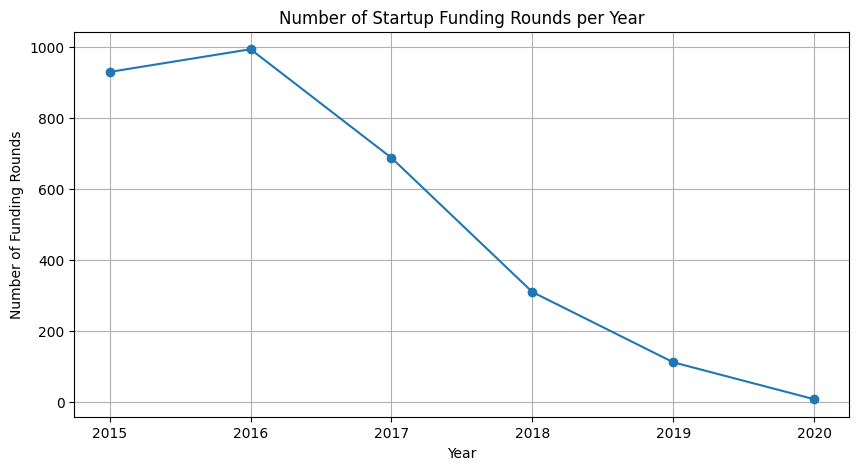

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
yearly_funding_count.plot(kind='line', marker='o')
plt.title("Number of Startup Funding Rounds per Year")
plt.xlabel("Year")
plt.ylabel("Number of Funding Rounds")
plt.grid(True)
plt.show()



## Interpretation

The analysis shows that startup funding activity increased from **929 funding rounds in 2015** to **993 funding rounds in 2016**, indicating a period of strong growth in the Indian startup ecosystem. However, from **2017 onwards**, the number of funding rounds declined steadily, dropping to **687 in 2017**, **309 in 2018**, **111 in 2019**, and only **7 in 2020**.

This indicates a significant slowdown in startup funding activity after 2016.

---

## Business Insight

The sharp increase in funding rounds during 2016 suggests a period of high investor confidence and rapid startup expansion in India. The continuous decline after 2016 may be attributed to changing market conditions, stricter investment strategies, startup consolidation, or incomplete data for later years (particularly 2020).

This trend highlights how external economic factors and investor sentiment can significantly influence startup funding.


---

## Recommendation

Entrepreneurs should study historical funding trends before planning fundraising activities and identify periods of strong investor participation. Investors can use trend analysis to understand market cycles and adjust their investment strategies accordingly.

Researchers should also verify whether the 2020 data is complete before drawing conclusions about recent funding activity.

---

## Key Observation

* **Highest funding activity:** **2016 (993 funding rounds)**
* **Lowest funding activity:** **2020 (7 funding rounds)**
* **Overall trend:** Rapid growth until 2016 followed by a steady decline.


# Total Funding Amount per Year

This visualization illustrates the total amount of funding received by startups each year. Analyzing yearly funding amounts helps identify investment trends, periods of high investor confidence, and changes in capital flow within the Indian startup ecosystem. It also enables comparison between the number of funding rounds and the overall investment value.

In [87]:
yearly_funding_amount = df.groupby('year')['amount_usd'].sum()
yearly_funding_amount# Total funding amount per year
yearly_funding_amount = df.groupby('year')['amount_usd'].sum()

# Convert to billions
yearly_funding_billion = yearly_funding_amount / 1e9

# Round to 2 decimal places
yearly_funding_billion = yearly_funding_billion.round(2)

yearly_funding_billion

,amount_usd
year,
2015.0,8.60
2016.0,3.83
2017.0,10.43
2018.0,5.12
2019.0,9.69
2020.0,0.39


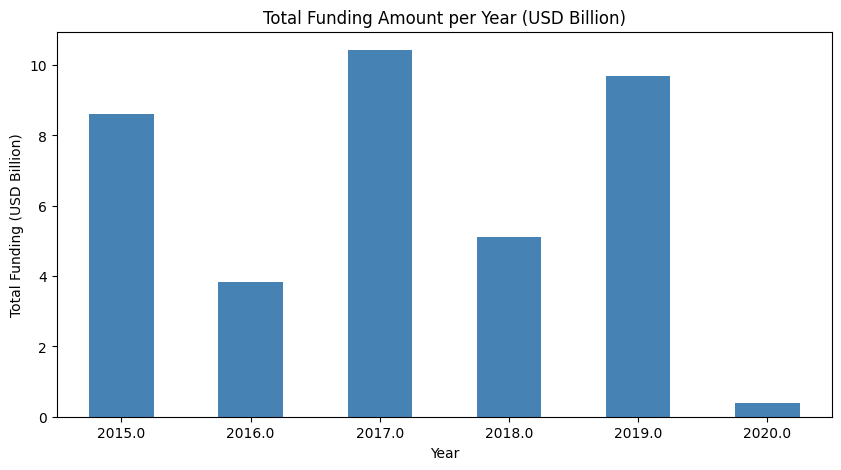

In [88]:
plt.figure(figsize=(10,5))

yearly_funding_billion.plot(kind='bar', color='steelblue')

plt.title("Total Funding Amount per Year (USD Billion)")
plt.xlabel("Year")
plt.ylabel("Total Funding (USD Billion)")

plt.xticks(rotation=0)

plt.show()


## Interpretation

The total funding amount varies significantly across the years.

* **2017** recorded the **highest total funding amount**, receiving approximately **USD 10.43 billion**, despite having fewer funding rounds than 2016.
* **2019** also witnessed substantial investments, with a total funding amount of approximately **USD 9.69 billion**.
* **2015** received around **USD 8.60 billion**, indicating a strong investment year.
* In contrast, **2016**, although it had the highest number of funding rounds, received only **USD 3.83 billion** in total funding.
* **2020** shows the lowest funding amount (approximately **USD 390 million**), but this should be interpreted carefully because the dataset contains only **7 funding records** for that year.

---

## Business Insight

The graph reveals that **the number of funding rounds does not necessarily correspond to the total amount invested**.

For example:

* **2016** had the highest number of funding rounds (**993**) but received a lower total investment than **2017**.
* **2017** had fewer funding rounds (**687**) yet attracted the largest overall investment.

This suggests that **2017 featured larger average deal sizes**, meaning investors made fewer but significantly bigger investments. Such a pattern may indicate a shift toward funding more mature or high-growth startups rather than distributing smaller investments across many early-stage companies.

---

## Recommendation

Investors should evaluate **both funding frequency and funding value** when analyzing startup ecosystems. A year with fewer funding rounds may still represent a highly attractive investment period if the average investment size is substantially larger.

Entrepreneurs should focus not only on securing investment but also on building scalable businesses capable of attracting larger funding rounds in later stages of growth.

Additionally, analysts should verify whether the **2020 data is complete** before drawing conclusions about investment performance for that year.

---

## Key Observations

| Year | Total Funding (Approx.) | Observation                                        |
| ---- | ----------------------: | -------------------------------------------------- |
| 2015 |    **USD 8.60 Billion** | Strong investment year                             |
| 2016 |    **USD 3.83 Billion** | Highest funding rounds, but lower total investment |
| 2017 |   **USD 10.43 Billion** | Highest total funding amount                       |
| 2018 |    **USD 5.12 Billion** | Moderate investment activity                       |
| 2019 |    **USD 9.69 Billion** | Significant increase in funding value              |
| 2020 |    **USD 0.39 Billion** | Likely incomplete dataset                          |

---

## Business Decision

This analysis demonstrates that **investment quality is as important as investment quantity**. Stakeholders should consider both the **number of funding rounds** and the **average funding size** to gain a more accurate understanding of investment trends and market maturity.


# City-wise Startup Funding
This visualization shows the top 10 cities based on the number of funded startups. Analyzing the geographical distribution of startup funding helps identify major startup ecosystems, investment hubs, and regions that attract the highest entrepreneurial activity in India.

In [89]:
top_cities = df['city'].value_counts().head(10)
top_cities

,count
city,
Bengaluru,841
Mumbai,567
New Delhi,421
Gurugram,337
Unknown,180
Pune,105
Hyderabad,99
Chennai,97
Noida,92


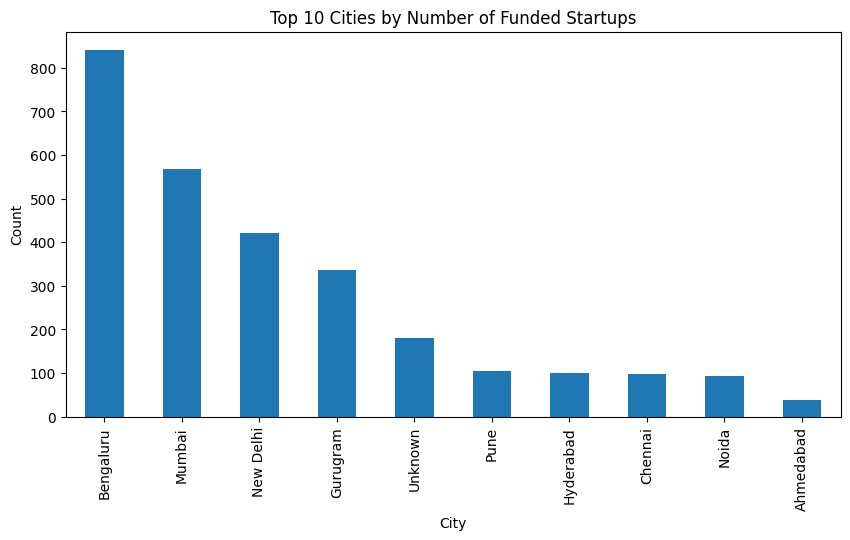

In [90]:
plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')
plt.title("Top 10 Cities by Number of Funded Startups")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

## Interpretation

The analysis reveals that **Bengaluru** is the leading startup hub with **841 funded startups**, followed by **Mumbai (567)** and **New Delhi (421)**. These three cities account for a significant share of startup funding in the dataset.

**Gurugram (337)** also emerges as an important startup ecosystem. The presence of **'Unknown' (180)** indicates that some records have missing city information, which should be considered while interpreting the results.

Cities such as **Pune (105)**, **Hyderabad (99)**, **Chennai (97)**, **Noida (92)**, and **Ahmedabad (38)** have comparatively fewer funded startups.

---
## Business Insight

The concentration of startup funding in Bengaluru, Mumbai, New Delhi, and Gurugram highlights the importance of well-established startup ecosystems. These cities provide access to venture capital firms, incubators, accelerators, skilled professionals, and business infrastructure, making them attractive locations for entrepreneurs and investors.

The presence of missing city information ('Unknown') also emphasizes the importance of data quality in business analytics. Incomplete location data may affect geographical analysis and business decision-making.

---
## Recommendation

Entrepreneurs seeking funding should consider building networks within major startup ecosystems such as Bengaluru, Mumbai, and New Delhi, where investor activity is highest.

Policymakers can encourage startup growth in emerging cities by improving infrastructure, providing financial incentives, and strengthening innovation support systems.

Before conducting further geographical analysis, missing city values should be investigated and cleaned wherever possible to improve the reliability of insights.

---
## Key Observations

- **Bengaluru** has the highest number of funded startups (**841**), making it the leading startup hub in the dataset.
- **Mumbai (567)** and **New Delhi (421)** are the second and third most active startup ecosystems.
- **Gurugram (337)** also plays a significant role in attracting startup investments.
- The presence of **180 'Unknown'** records indicates missing location information, highlighting a data quality issue.
- Other cities such as **Pune, Hyderabad, Chennai, Noida, and Ahmedabad** have comparatively fewer funded startups.

# Industry-wise Analysis
This visualization presents the top 10 industry verticals based on the number of funded startups. Analyzing industry-wise funding helps identify sectors that attract the highest investor interest and highlights emerging business opportunities within the startup ecosystem.

In [91]:
top_industries = df['industry_vertical'].value_counts().head(10)
top_industries

,count
industry_vertical,
Consumer Internet,941
Technology,478
eCommerce,186
Unknown,171
Healthcare,70
Finance,62
ECommerce,61
Logistics,32
E-Commerce,29


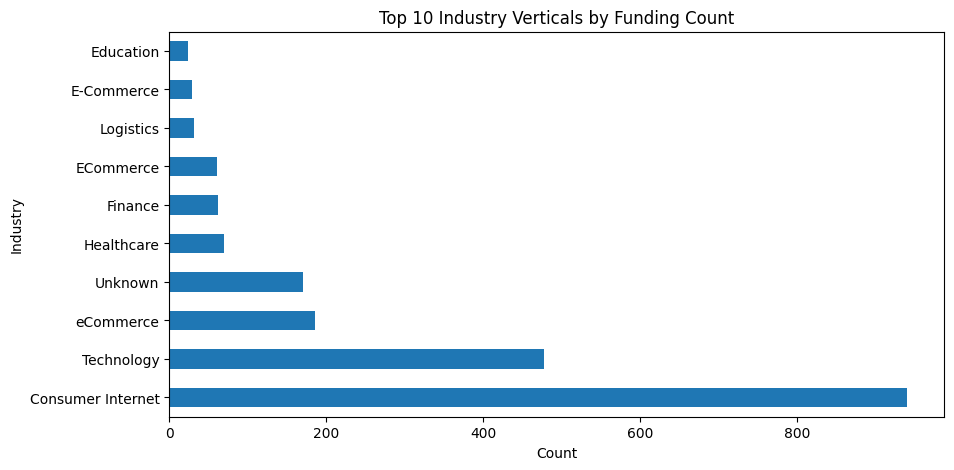

In [92]:
plt.figure(figsize=(10,5))
top_industries.plot(kind='barh')
plt.title("Top 10 Industry Verticals by Funding Count")
plt.xlabel("Count")
plt.ylabel("Industry")
plt.show()

## Interpretation

The analysis shows that **Consumer Internet** is the most funded industry with **941 startups**, followed by **Technology (478)** and **eCommerce (186)**.

The dataset also contains **171 records labeled as 'Unknown'**, indicating missing industry information. Additionally, similar categories such as **eCommerce (186)**, **ECommerce (61)**, and **E-Commerce (29)** appear separately due to inconsistent naming, which affects the accuracy of the analysis.

Other industries such as **Healthcare (70)**, **Finance (62)**, **Logistics (32)**, and **Education (24)** receive comparatively fewer funding rounds.

---
## Business Insight

The dominance of Consumer Internet and Technology startups indicates strong investor confidence in digital businesses and technology-driven solutions. These sectors typically offer high scalability, rapid customer acquisition, and significant growth potential.

The presence of multiple naming variations for the same industry (eCommerce, ECommerce, and E-Commerce) highlights the importance of data standardization during preprocessing. Standardizing these categories would provide a more accurate representation of industry-wise funding trends.

---
## Recommendation

Entrepreneurs can use this analysis to identify industries that consistently attract investor attention, particularly Consumer Internet and Technology.

Before performing industry-level analysis, similar category names should be standardized (for example, combining eCommerce, ECommerce, and E-Commerce into a single category) to improve the reliability of the results.

Organizations should also investigate records with 'Unknown' industry labels to reduce missing data and enable more accurate business insights.

---
## Key Observations

- **Consumer Internet** is the leading industry with **941 funded startups**.
- **Technology** ranks second with **478 funded startups**.
- **eCommerce-related categories** appear under different names (eCommerce, ECommerce, and E-Commerce), indicating inconsistent data entry.
- **171 records** have an **Unknown** industry, highlighting missing data.
- Healthcare, Finance, Logistics, and Education receive comparatively fewer funding rounds than the leading sectors.

# Investment Type Analysis
This visualization illustrates the distribution of different investment types in the startup ecosystem. Analyzing investment types helps understand the stages at which startups receive funding and provides insights into investor preferences across different phases of business growth.

In [93]:
investment_counts = df['investment_type'].value_counts()
investment_counts

,count
investment_type,
Private Equity,1356
Seed Funding,1355
Seed/ Angel Funding,60
Seed / Angel Funding,47
Seed\\nFunding,30
Debt Funding,25
Series A,24
Seed/Angel Funding,23
Series B,20


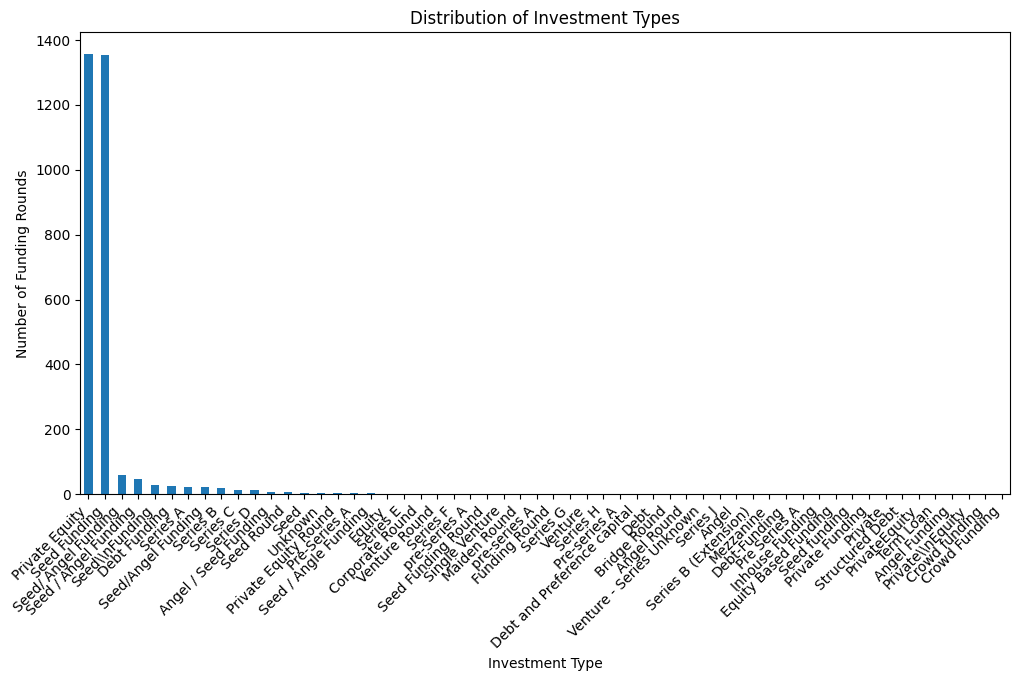

In [94]:
plt.figure(figsize=(12,6))
investment_counts.plot(kind='bar')
plt.title("Distribution of Investment Types")
plt.xlabel("Investment Type")
plt.ylabel("Number of Funding Rounds")
plt.xticks(rotation=45, ha='right')
plt.show()

## Interpretation

The analysis indicates that **Private Equity (1356)** and **Seed Funding (1355)** are the two most common investment types in the dataset, contributing to the majority of funding rounds.

Several investment types such as **Series A (24)**, **Series B (20)**, **Series C (14)**, and **Debt Funding (25)** occur less frequently, while many other categories appear only once or a few times.

The dataset also contains multiple naming variations for the same investment type, such as *Seed Funding*, *Seed funding*, *Seed Round*, *Seed/Angel Funding*, and *Seed / Angel Funding*, indicating inconsistent data entry.

---
## Business Insight

The dominance of Seed Funding and Private Equity indicates that startups receive significant investment during their early growth stages as well as during later expansion phases.

The presence of numerous naming inconsistencies suggests that the dataset requires further standardization before performing detailed investment-type analysis. Combining similar investment categories would provide a more accurate representation of investor preferences.

---
## Recommendation

Organizations should standardize investment type names during data preprocessing to eliminate duplicate categories caused by inconsistent formatting, spelling, and capitalization.

Entrepreneurs can use this analysis to understand the funding stages most commonly supported by investors and prepare appropriate fundraising strategies based on their startup's growth stage.

Future analyses should merge similar categories such as different variations of Seed Funding and Private Equity to improve the accuracy of business insights.

---
## Key Observations

- **Private Equity (1356)** is the most common investment type in the dataset.
- **Seed Funding (1355)** is almost equally common, highlighting strong investment in early-stage startups.
- Series funding (Series A, B, C, D, etc.) occurs less frequently than Seed Funding and Private Equity.
- Multiple naming variations exist for the same investment types, indicating inconsistent data entry.
- The dataset contains a large number of categories with very few records, which could be grouped into broader investment stages for better analysis.

## Distribution of Investment Types (Pie Chart)
This pie chart shows the proportion of different investment types in the startup ecosystem. It provides an overview of how startup funding is distributed across various funding stages and investment categories.

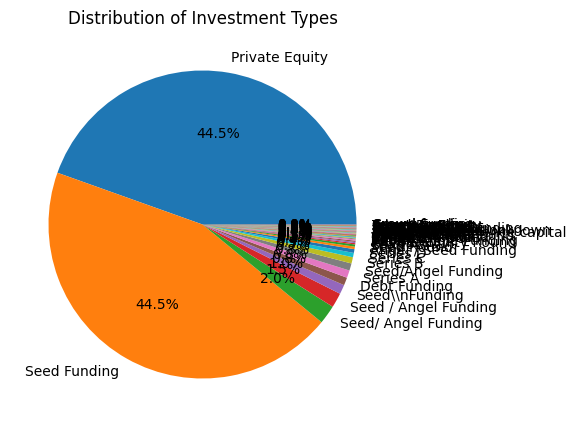

In [95]:
plt.figure(figsize=(8,5))
investment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribution of Investment Types")
plt.ylabel("")
plt.show()

## Interpretation

The pie chart indicates that **Private Equity** and **Seed Funding** together account for the majority of funding rounds. However, due to the large number of investment categories, the chart becomes difficult to interpret, especially for categories with very small proportions.

---
## Business Insight

The visualization highlights the dominance of early-stage and private equity investments. However, the presence of numerous small categories and inconsistent naming makes it difficult to clearly understand the overall distribution. Grouping similar categories improves the clarity and usefulness of the visualization.

---
## Recommendation

To improve readability, similar investment types should be standardized and less frequent categories should be grouped together. This allows stakeholders to focus on the most significant funding patterns without losing important information.

## Distribution of Investment Types (Top 5 + Others)
This visualization groups the five most common investment types while combining all remaining categories into an **Others** group. This simplifies the distribution and provides a clearer understanding of the dominant investment patterns.

In [96]:
#Keep Top 5, group rest as “Others”
top_5 = investment_counts.head(5)
others = investment_counts[5:].sum()

investment_clean = pd.concat([
    top_5,
    pd.Series({'Others': others})
])

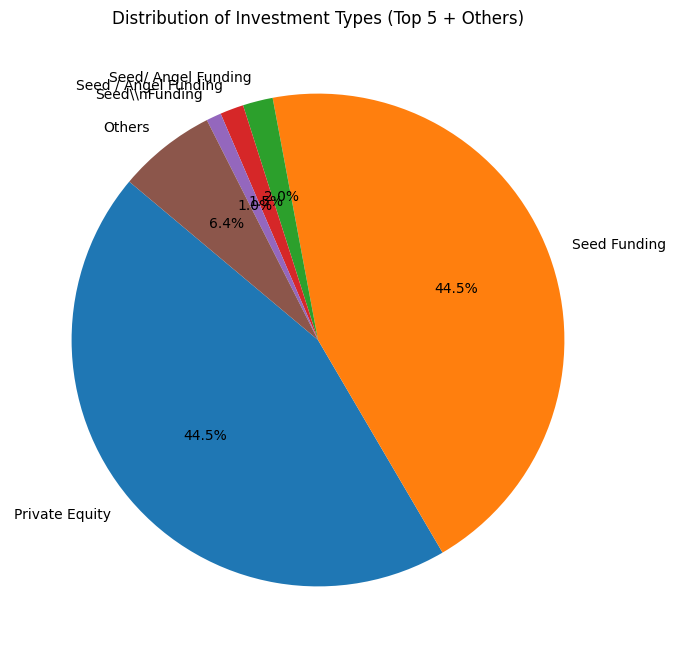

In [97]:
plt.figure(figsize=(8,8))
investment_clean.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Distribution of Investment Types (Top 5 + Others)")
plt.ylabel("")
plt.show()

## Interpretation

The chart clearly shows that **Private Equity** and **Seed Funding** dominate the startup funding landscape, accounting for the largest share of funding rounds. The remaining investment types collectively contribute a smaller proportion and are grouped into the **Others** category for better visualization.

---
## Business Insight

The dominance of Private Equity and Seed Funding indicates that investors actively support startups during both early-stage development and business expansion. Grouping less frequent investment types into **Others** improves visualization clarity while preserving the overall distribution of investment activity.

---
## Recommendation

For reporting and dashboard development, grouping less significant categories into **Others** is a good visualization practice because it improves readability and highlights the most important investment patterns. Additionally, similar investment type names should be standardized before analysis to ensure accurate results.

---
## Key Observations

- **Private Equity** and **Seed Funding** together account for the largest share of funding rounds.
- Most of the remaining investment types occur relatively infrequently.
- Grouping smaller categories into **Others** makes the distribution easier to interpret.
- Standardizing investment type names would further improve the accuracy of the analysis.

# Top Investors (Most Active)
This visualization displays the top 10 most active investors based on the number of startup investments. Analyzing investor participation helps identify key contributors to the startup ecosystem and understand investment patterns across different startups.

In [98]:
top_investors = df['investors'].value_counts().head(10)
top_investors

,count
investors,
Undisclosed Investors,39
Undisclosed investors,30
Ratan Tata,25
Unknown,24
Indian Angel Network,23
Kalaari Capital,16
Group of Angel Investors,15
Sequoia Capital,15
Undisclosed Investor,12


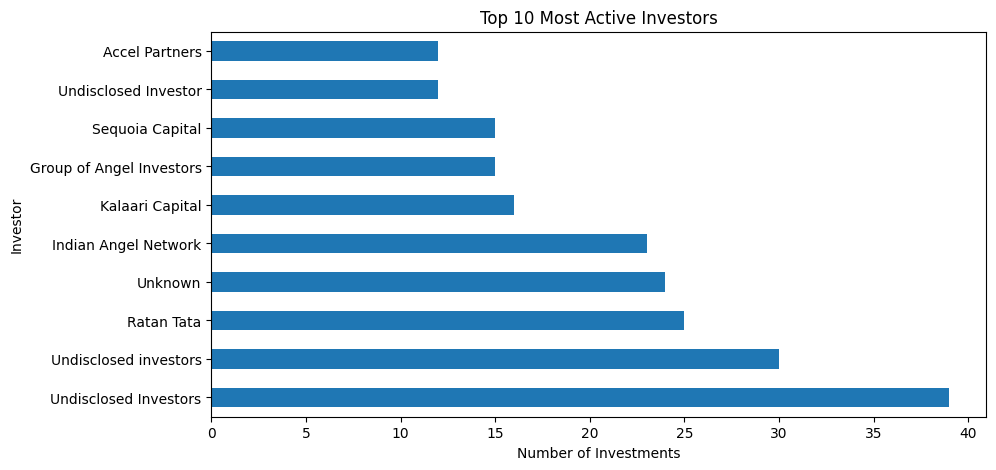

In [99]:
plt.figure(figsize=(10,5))
top_investors.plot(kind='barh')
plt.title("Top 10 Most Active Investors")
plt.xlabel("Number of Investments")
plt.ylabel("Investor")
plt.show()

## Interpretation

The analysis shows that **Undisclosed Investors (39)** appears as the most frequent investor category, followed by **Undisclosed investors (30)** and **Undisclosed Investor (12)**. These represent the same category but are treated separately due to inconsistent naming.

Among the identified investors, **Ratan Tata (25)** is the most active, followed by **Indian Angel Network (23)**, **Kalaari Capital (16)**, **Group of Angel Investors (15)**, **Sequoia Capital (15)**, and **Accel Partners (12)**.

The presence of **Unknown (24)** indicates that investor information is missing for several funding records.

---
## Business Insight

The analysis highlights the significant role of individual investors and venture capital firms in supporting startup growth. Investors such as Ratan Tata, Indian Angel Network, Kalaari Capital, Sequoia Capital, and Accel Partners have consistently participated in multiple funding rounds, demonstrating their active involvement in the Indian startup ecosystem.

The presence of multiple naming variations for "Undisclosed Investors" and missing investor information ("Unknown") indicates data quality issues that should be addressed before drawing final conclusions.

---
## Recommendation

Investor names should be standardized by combining similar entries such as "Undisclosed Investors", "Undisclosed investors", and "Undisclosed Investor" into a single category. This will provide a more accurate representation of investor activity.

Organizations should also investigate missing investor information where possible to improve data completeness and support more reliable investment analysis.

---
## Key Observations

- **Ratan Tata (25)** is the most active identified investor in the dataset.
- **Indian Angel Network (23)** ranks as the second most active identified investor.
- Venture capital firms such as **Kalaari Capital**, **Sequoia Capital**, and **Accel Partners** have consistently invested in startups.
- Multiple variations of **"Undisclosed Investors"** appear separately due to inconsistent naming.
- **Unknown (24)** records indicate missing investor information, highlighting a data quality issue.

In [100]:
# Standardize investor names
df['investors'] = df['investors'].replace({
    'Undisclosed investors': 'Undisclosed Investors',
    'Undisclosed Investor': 'Undisclosed Investors'
})

In [101]:
df['investors'].value_counts().head(10)

,count
investors,
Undisclosed Investors,81
Ratan Tata,25
Unknown,24
Indian Angel Network,23
Kalaari Capital,16
Sequoia Capital,15
Group of Angel Investors,15
Accel Partners,12
Undisclosed,11


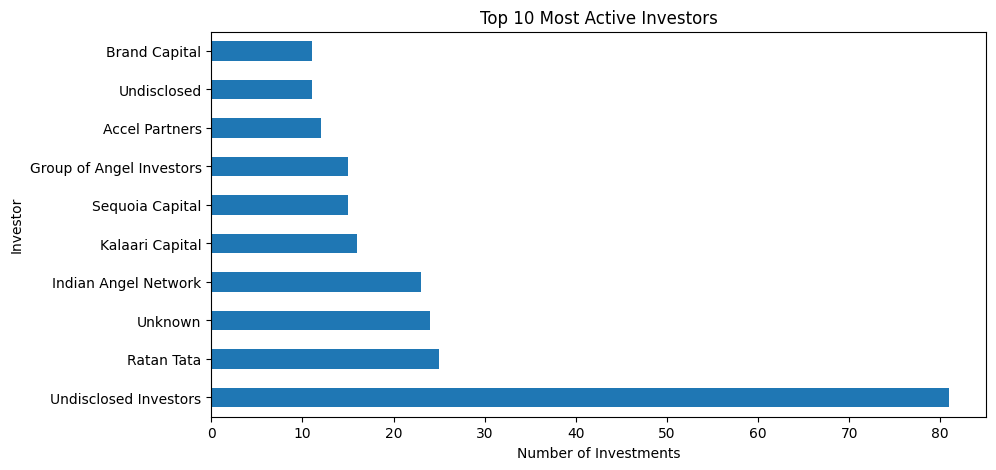

In [102]:
top_investors = df['investors'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_investors.plot(kind='barh')

plt.title("Top 10 Most Active Investors")
plt.xlabel("Number of Investments")
plt.ylabel("Investor")

plt.show()

# Industry-wise Funding Amount
This visualization shows the top 10 industries based on the total funding amount received. Analyzing funding value across industries helps identify sectors that attract the largest investments and highlights areas with strong growth potential in the startup ecosystem.

In [103]:
# Convert funding amount to billions
industry_funding = (
    df.groupby('industry_vertical')['amount_usd']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      / 1e9
).round(2)

industry_funding

,amount_usd
industry_vertical,
Consumer Internet,6.25
eCommerce,5.00
Transportation,3.92
Technology,2.23
Finance,1.97
ECommerce,1.88
Unknown,1.23
FinTech,1.22
E-Commerce,1.01


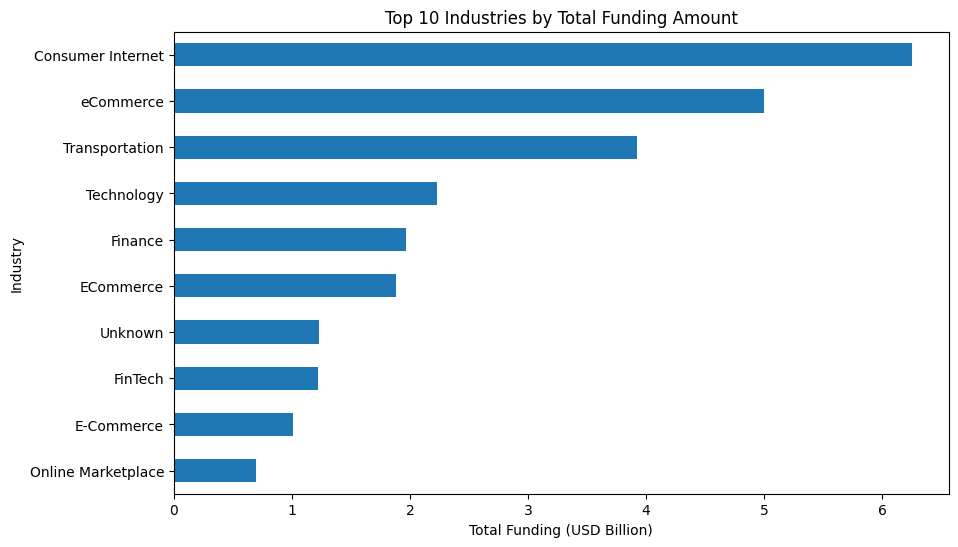

In [104]:
plt.figure(figsize=(10,6))
industry_funding.plot(kind='barh')
plt.title("Top 10 Industries by Total Funding Amount")
plt.xlabel("Total Funding (USD Billion)")
plt.ylabel("Industry")
plt.gca().invert_yaxis()
plt.show()


## Interpretation

The analysis shows that **Consumer Internet** received the highest total funding of approximately **USD 6.25 billion**, followed by **eCommerce (USD 5.00 billion)** and **Transportation (USD 3.92 billion)**.

Technology and Finance also attracted significant investments, receiving approximately **USD 2.23 billion** and **USD 1.97 billion**, respectively.

The dataset contains multiple naming variations such as **eCommerce**, **ECommerce**, and **E-Commerce**, which represent the same industry but are treated as separate categories. Additionally, **Unknown** accounts for approximately **USD 1.23 billion**, indicating missing industry information.

---
## Business Insight

The high funding received by Consumer Internet, eCommerce, and Transportation reflects strong investor confidence in industries driven by digital transformation, online services, and scalable business models.

However, inconsistent naming of industry categories results in fragmented analysis. If the three eCommerce categories were combined, they would collectively receive approximately **USD 7.89 billion**, making eCommerce the highest-funded industry in the dataset.

This demonstrates the importance of data standardization before performing business analysis.

---
## Recommendation

Organizations should standardize industry names during data preprocessing by merging similar categories such as **eCommerce**, **ECommerce**, and **E-Commerce** into a single category.

Entrepreneurs can use this analysis to identify industries with strong investment potential, while investors can better understand sectors that consistently attract high-value funding.

Records with **Unknown** industry labels should also be reviewed to improve data completeness and the accuracy of future analyses.

---
## Key Observations

- **Consumer Internet** received the highest recorded funding at approximately **USD 6.25 billion**.
- **eCommerce-related categories** appear separately due to inconsistent naming.
- Combining **eCommerce**, **ECommerce**, and **E-Commerce** results in approximately **USD 7.89 billion**, making it the highest-funded industry.
- Transportation and Technology also attracted substantial investments.
- Approximately **USD 1.23 billion** is associated with **Unknown** industries, indicating missing data.

# City-wise Funding Amount
This visualization presents the top 10 cities based on the total funding amount received by startups. It helps identify the major investment hubs and highlights the geographical distribution of startup funding across different locations.

In [105]:
# Convert total funding to billions
city_funding = (
    df.groupby('city')['amount_usd']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      / 1e9
).round(2)

city_funding

,amount_usd
city,
Bengaluru,18.46
Mumbai,4.92
Gurugram,3.87
New Delhi,3.02
Unknown,1.27
Noida,1.26
Chennai,0.72
Pune,0.63
Menlo Park,0.45


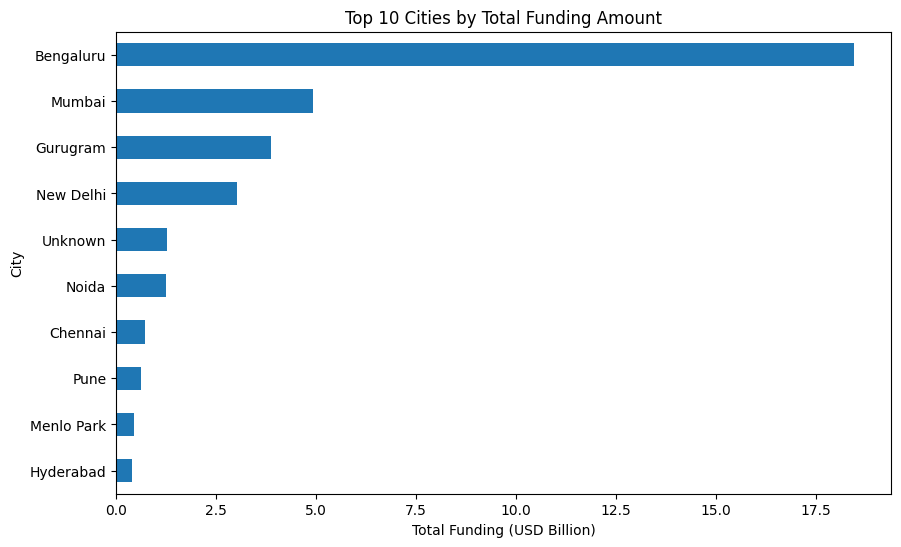

In [106]:
plt.figure(figsize=(10,6))
city_funding.plot(kind='barh')
plt.title("Top 10 Cities by Total Funding Amount")
plt.xlabel("Total Funding (USD Billion)")
plt.ylabel("City")
plt.gca().invert_yaxis()
plt.show()

## Interpretation

The analysis shows that **Bengaluru** received the highest total funding of approximately **USD 18.46 billion**, significantly exceeding all other cities. **Mumbai** ranks second with approximately **USD 4.92 billion**, followed by **Gurugram (USD 3.87 billion)** and **New Delhi (USD 3.02 billion)**.

The dataset also contains **Unknown** city entries with approximately **USD 1.27 billion** in funding, indicating missing location information. Additionally, **Menlo Park** appears among the top-funded locations, suggesting that some funding records are associated with locations outside India or contain location inconsistencies.

---
## Business Insight

The concentration of funding in Bengaluru demonstrates its position as India's leading startup ecosystem, supported by strong venture capital presence, skilled talent, technology companies, and startup infrastructure.

Mumbai, Gurugram, and New Delhi also attract substantial investments, highlighting their importance as major business and innovation hubs.

The presence of missing and potentially inconsistent location data emphasizes the importance of data validation before performing geographical analysis.

---
## Recommendation

Entrepreneurs seeking investment opportunities can benefit from building networks within major startup hubs such as Bengaluru, Mumbai, Gurugram, and New Delhi, where investor activity is highest.

Before conducting location-based analysis, missing city information should be investigated, and inconsistent location names should be standardized to improve the accuracy of business insights.

---
## Key Observations

- **Bengaluru** received the highest total funding at approximately **USD 18.46 billion**.
- **Mumbai**, **Gurugram**, and **New Delhi** are the next largest investment hubs.
- Approximately **USD 1.27 billion** in funding is associated with **Unknown** city values, indicating missing location data.
- **Menlo Park** appears among the top-funded locations, suggesting possible international startup locations or inconsistent location records.
- Startup funding is highly concentrated in a small number of major cities.

## Comparison with City-wise Funding Count

While Bengaluru ranks first in both the number of funded startups and the total funding amount, the ranking of other cities differs when funding value is considered. This indicates that some cities receive fewer investments but attract larger funding amounts per startup, highlighting the importance of analyzing both funding frequency and funding value for a comprehensive understanding of the startup ecosystem.

# Top Funded Startups
This visualization highlights the top 10 startups based on the total funding amount received. It helps identify companies that have attracted the largest investments and provides insights into investor confidence in high-growth startups.

In [107]:
startup_funding = (
    df.groupby('startup_name')['amount_usd']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      / 1e9
).round(2)

startup_funding

,amount_usd
startup_name,
Flipkart,4.06
Rapido Bike Taxi,3.90
Paytm,3.15
Ola,0.98
Udaan,0.87
Snapdeal,0.70
Flipkart.com,0.70
Ola Cabs,0.67
True North,0.60


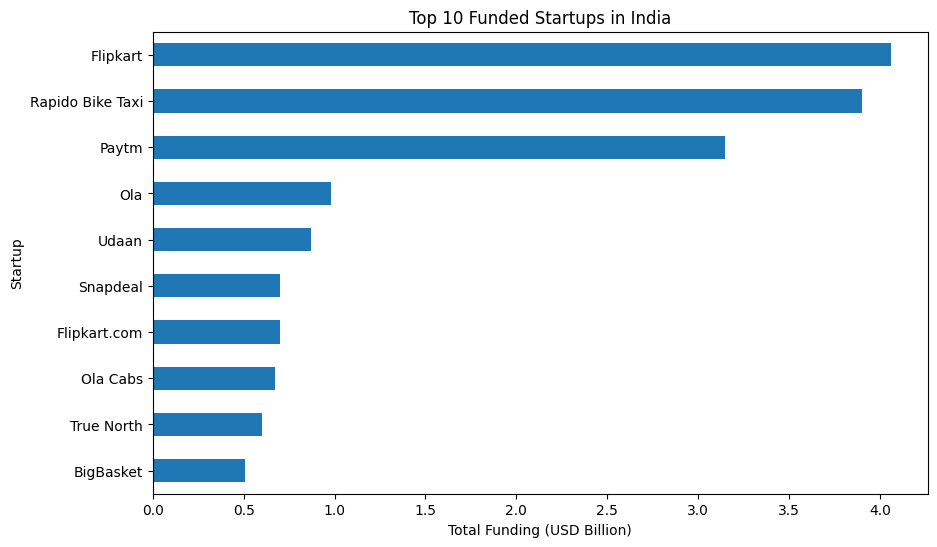

In [108]:
plt.figure(figsize=(10,6))
startup_funding.plot(kind='barh')
plt.title("Top 10 Funded Startups in India")
plt.xlabel("Total Funding (USD Billion)")
plt.ylabel("Startup")
plt.gca().invert_yaxis()
plt.show()

## Interpretation

The analysis shows that **Flipkart** received the highest recorded funding of approximately **USD 4.06 billion**, followed by **Rapido Bike Taxi (USD 3.90 billion)** and **Paytm (USD 3.15 billion)**.

Other highly funded startups include **Ola (USD 0.98 billion)**, **Udaan (USD 0.87 billion)**, **Snapdeal (USD 0.70 billion)**, **Flipkart.com (USD 0.70 billion)**, **Ola Cabs (USD 0.67 billion)**, **True North (USD 0.60 billion)**, and **BigBasket (USD 0.51 billion)**.

The dataset also contains startup name variations such as **Flipkart** and **Flipkart.com**, as well as **Ola** and **Ola Cabs**, which likely refer to the same companies but are treated as separate entities.

---
## Business Insight

The funding distribution indicates that investors are willing to make exceptionally large investments in startups with proven business models and strong market potential. Companies operating in sectors such as e-commerce, fintech, mobility, and quick commerce dominate the list of top-funded startups.

The presence of multiple naming variations for the same startup demonstrates the importance of data standardization. Combining similar startup names would provide a more accurate representation of total funding received by each company.

---
## Recommendation

Before performing startup-level funding analysis, company names should be standardized by merging duplicate entries such as **Flipkart** and **Flipkart.com**, as well as **Ola** and **Ola Cabs**.

Investors can use this analysis to identify sectors that consistently attract large investments, while entrepreneurs can study the growth strategies of highly funded startups to understand factors contributing to investor confidence.

---
## Key Observations

- **Flipkart** received the highest recorded funding at approximately **USD 4.06 billion**.
- **Rapido Bike Taxi** and **Paytm** are the second and third highest-funded startups.
- Startups in **e-commerce**, **fintech**, and **mobility** dominate the list of top-funded companies.
- Startup name variations such as **Flipkart/Flipkart.com** and **Ola/Ola Cabs** indicate inconsistent data entry.
- Standardizing startup names would provide a more accurate ranking of funded startups.

# Funding Amount Distribution & Outliers

This histogram illustrates the distribution of startup funding amounts. It helps understand how funding is spread across startups and whether most companies receive small, moderate, or large investments.

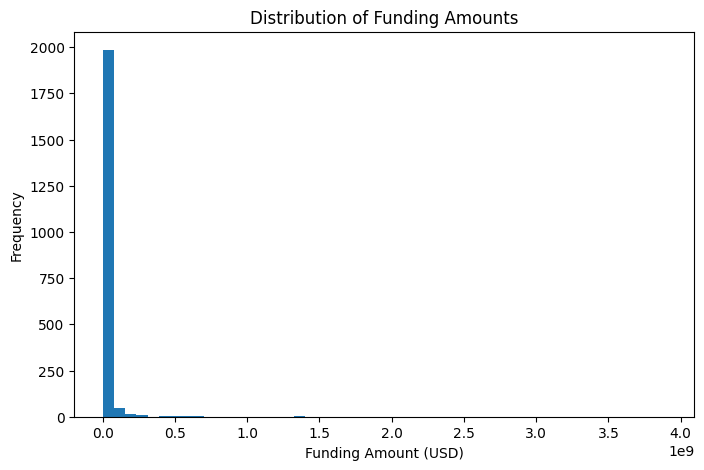

In [109]:
#distribution plot
plt.figure(figsize=(8,5))
df['amount_usd'].dropna().plot(kind='hist', bins=50)
plt.title("Distribution of Funding Amounts")
plt.xlabel("Funding Amount (USD)")
plt.ylabel("Frequency")
plt.show()





## Interpretation

- The funding amount distribution is **highly right-skewed**, with the majority of startups receiving relatively small investments.
- Only a small number of startups secured exceptionally large funding amounts, creating a long tail on the right side of the distribution.
- The histogram indicates that startup funding is **not evenly distributed**, as most funding rounds are concentrated in the lower investment ranges.
- These extreme funding amounts (outliers) significantly influence the overall distribution.

---

## Business Insight

- The startup funding ecosystem follows a **"winner-takes-most"** pattern, where only a few startups attract very large investments.
- Investors generally prefer making smaller investments across many startups while reserving large funding rounds for companies with proven growth potential.
- Since the funding data is highly skewed, the **median funding amount** provides a more reliable measure of a typical investment than the average.

---

## Recommendation

- Investors should diversify their portfolios by balancing investments between early-stage startups and high-growth companies.
- Entrepreneurs should focus on demonstrating product-market fit and strong business performance rather than expecting very large funding rounds in the early stages.
- Analysts should consider applying **log transformation** or using the median during statistical analysis to reduce the impact of extreme values.

---

## Key Observations

-  The funding distribution is **highly right-skewed**.
-  Most startups receive **small to moderate funding amounts**.
-  Only a few startups receive **very large investments**, creating significant outliers.
-  The presence of extreme funding values makes the dataset **non-normally distributed**.

# Funding Amount Outliers (Box Plot)

### Description
This box plot is used to identify outliers in startup funding amounts. Outliers represent startups that have received significantly higher investments compared to the majority of the dataset, helping reveal the spread and variability of funding.


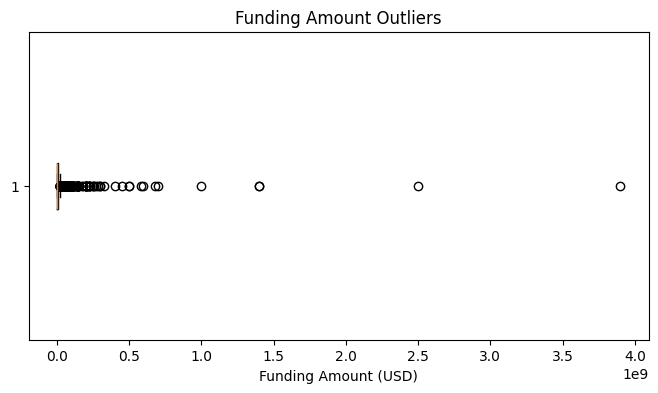

In [110]:
#box plot(outliers)
plt.figure(figsize=(8,4))
plt.boxplot(df['amount_usd'].dropna(), vert=False)
plt.title("Funding Amount Outliers")
plt.xlabel("Funding Amount (USD)")
plt.show()




## Interpretation

- The box plot reveals that **most startup funding amounts are concentrated within a relatively small range**, as indicated by the compact box.
- A large number of data points appear beyond the upper whisker, representing **significant outliers** with exceptionally high funding amounts.
- These outliers indicate that only a few startups secured investments that are substantially larger than the majority.
- The presence of numerous outliers confirms that the funding data is **highly skewed** and contains considerable variation.

---

## Business Insight

- A small number of high-performing or well-established startups attract a disproportionately large share of total investment.
- Investors are highly selective when making large funding decisions, reserving substantial investments for startups with strong growth potential, proven business models, or market leadership.
- Since extreme funding rounds heavily influence the dataset, relying solely on the **mean funding amount** may provide a misleading representation of typical startup investments.

---

## Recommendation

- Analysts should use the **median** and **interquartile range (IQR)** alongside the mean when summarizing funding data.
- Outliers should be examined separately, as they often represent unicorns or high-growth startups with unique investment characteristics.
- Before building predictive models, consider applying **log transformation**, **outlier treatment**, or **segmentation by funding stage** to improve model accuracy.
- Entrepreneurs should recognize that exceptionally large funding rounds are uncommon and focus on achieving sustainable growth milestones.

---

## Key Observations

-  Most funding amounts are concentrated within a narrow range.
-  Numerous high-value funding rounds appear as **outliers**.
-  Funding distribution shows **high variability** due to a few exceptionally large investments.
-  The presence of many outliers confirms that the funding data is **not normally distributed**.
-  A small number of startups account for a significant share of total investment value.

---
---

# Key Findings

- Startup funding activity reached its highest number of funding rounds in **2016**, indicating a period of strong investor participation.
- Although **2016** had the highest number of funding rounds, **2017** recorded the highest total funding amount, suggesting larger average investment sizes.
- **Bengaluru** emerged as India's leading startup hub in terms of both funding count and total funding amount.
- **Consumer Internet** and **Technology** attracted the highest number of funding rounds, while **Consumer Internet** and **eCommerce** received the largest funding amounts.
- **Private Equity** and **Seed Funding** accounted for the majority of investment rounds, highlighting strong support for startups across different growth stages.
- Funding amounts were highly skewed, with only a small number of startups receiving exceptionally large investments.
- Several data quality issues were identified, including inconsistent naming conventions, duplicate categories, and missing values, emphasizing the importance of data preprocessing before analysis.

# Business Impact

The insights obtained from this analysis can benefit multiple stakeholders within the startup ecosystem.

### Investors
- Identify industries and cities that consistently attract high-value investments.
- Understand historical funding patterns to support investment decisions.

### Entrepreneurs
- Recognize sectors with strong investor interest.
- Select strategic locations with well-developed startup ecosystems.
- Understand common funding stages and investment preferences.

### Policymakers
- Promote startup development in emerging cities by improving infrastructure and funding accessibility.
- Design initiatives that encourage balanced regional startup growth.

### Researchers and Analysts
- Use the cleaned dataset and findings as a foundation for predictive modeling, funding trend analysis, and startup success prediction.

# Future Scope

This project can be extended in several ways:

- Build machine learning models to predict startup funding amounts.
- Develop a startup success prediction model based on funding history and company characteristics.
- Perform time-series forecasting to analyze future investment trends.
- Create an interactive dashboard using Power BI or Tableau for real-time business insights.
- Integrate additional datasets such as startup valuation, employee count, or financial performance for deeper analysis.

# Conclusion

This project successfully explored startup funding trends in India through comprehensive exploratory data analysis (EDA). The dataset was cleaned, preprocessed, and analyzed using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn to uncover meaningful patterns in startup funding.

The analysis identified major startup hubs, leading industries, active investors, preferred investment types, and funding distribution patterns. It also highlighted the importance of data cleaning by identifying missing values, inconsistent category names, and duplicate records that could affect business insights.

Overall, this project demonstrates the practical application of data analysis techniques to transform raw startup funding data into actionable business insights. The findings can support investors, entrepreneurs, researchers, and policymakers in understanding the Indian startup ecosystem and serve as a strong foundation for future predictive analytics and machine learning applications.

---
---